<a href="https://colab.research.google.com/github/pc-repo/algorytmy-ewolucyjne/blob/main/AE_L3_65456_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AE_Lab_3**
Operacje ewolucyjne i genetyczne - zastosowania różnych strategii

###**Zad. 1.** Kod algorytmu ewolucyjnego z Lab.1 zadania 5 uzupełnij tak, aby sprawdzić działanie strategii elitarnej przy selekcji. Przeanalizuj zmiany wartości na wykresie w kolejnych pokoleniach. Na końcu, w komórce tekstowej, przedstaw wnioski wynikające z porównania modelu z poprzednim.

Część I - definicje wstępne

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Definicja funkcji zadanej f(x)
def f(x):
  return x + np.abs(np.sin(32*x))

# Parametry inicjacji algorytmu ewolucyjnego
x_min, x_max = 0, 4             # Zakres dziedziny
population_size = 70            # Liczność populacji
max_iterns = 30                # Liczba iteracji
mutation_rate = 0.01            # Wskaźnik szybkości mutacji
crossover_rate = 0.7            # Wskaźnik szybkości krzyżowania

# Definicja zmiennych pomocniczych - tablic dopasowania w kolejnych pokoleniach
best_fit = []
worst_fit = []
avg_fit = []

# Definicja populacji
population = np.random.uniform(0, 4, population_size)   # Losowanie osobników

Część II - Moduł selekcji elitarnej

In [ ]:
# Selekcja najlepiej przystosowanych osobników (definicja funkcji selekcji)
def selection(population):
  fit = np.array([f(x) for x in population])    # Funkcja celu (dopasowania)
  indexes = np.argsort(fit)[-2:]                # Wybór najlepiej przystosowanych osobników
  return population[indexes]                    # Zwracamy tych dwóch najlepszych

W tej części jest zastosowany jako sposób selekcji (kryterium wyboru osobników) algorytm selekcji elitarnej. Polega z grubsza na wyborze najlepiej przystosowanych osobników. Stąd nawiązanie do terminu "elitarności".

Algorytm ten był użyty przeze mnie już w zadaniu 5 laboratorium 1. Tu przedstawię go odrobinę szerzej.

Funkcja przyjmuje jeden argument, którym jest tablica populacji (population), zawierającą wartości cech, losowo wybrane uprzednio w procesie generowania populacji funkcją <np.random.uniform>.

 Następnie jest wyznaczana funkcja celu (fit) dla każdego osobnika jako tablica wartości, za co odpowiada pętla <for>. Obliczne jest tu dopasowanie wg. wzoru funkcji zadanej - f(x). Funkcja <np.array> wypełnia tablicę (fit) wartościami.

Następnie lista dopasowań (fit) jest sortowana funkcją <np.argsort>, która losuje rosnąco. Zatem dwa najlepsze osobniki (elitarne), które chcemy wybrać znajdują się na końcu listy, tzn. na dwóch ostatnich indeksach. Wprowadzamy zmienną pomocniczą do przechowywania tych indeksów (indexes). Aby wskazać dwa ostatnie indeksy, bez względu na długość tablicy populacji (a także i dopasowania, bo mają ten sam rozmiar) z funkcji sortowania pobieramy dwa ostatnie, używając składni [-2:], która wskazuje na  dwa indeksy brane z końca tablicy. To zapewnia elastyczność obliczeń i zmianę wielkości tablicy populacji bez zmian w kodzie samej selekcji.

Funkcja <selection(population)> zwraca wartości dwóch elitarnych - najlepiej przystosowanych osobników wg. dwóch ostatnich indeksów z posortowanej rosnąco tablicy dopasowań (population[indexes])

Część III - Moduł mutacja i krzyżowanie

In [ ]:
# Krzyżowanie cech/genów dla 2-ch osobnoków
def crossover(parent1, parent2):
  if np.random.random() < crossover_rate:       # Prawdopodobieństwo krzyżowania
    return (parent1 + parent2) / 2              # Średnia jeśli skrzyżowano
  return parent1                             # Cechy pierwszego w całości

# Mutowanie cech - zmiana wartości (względnie małego rzędu)
def mutation(x):
  if np.random.random() < mutation_rate:         # Prawdopodobieństwo mutacji
    x = x + (np.random.uniform(-0.1, 0.1))       # Mutowanie wartością z przedziału [-0.1, 0.1]
    x = np.clip(x, x_min, x_max)                 # Strażnnik wartości granicznych
  return x                                       # Zwraca nowego osobnika

Część IV - Pętla programu i generowanie wykresu

Numer pokolenia 1
Najlepszy osobnik: f(x) = 4.375821683056063 dla x = 3.70777957191568
Najgorszy osobnik: f(x) = 4.28576139814187 dla x = 3.8431446328309744
Średnia populacji: 4.305060030623481
Liczba najlepszych osobników: 15


Numer pokolenia 2
Najlepszy osobnik: f(x) = 4.375821683056063 dla x = 3.70777957191568
Najgorszy osobnik: f(x) = 4.375821683056063 dla x = 3.70777957191568
Średnia populacji: 4.3758216830560634
Liczba najlepszych osobników: 70


Numer pokolenia 3
Najlepszy osobnik: f(x) = 4.375821683056063 dla x = 3.70777957191568
Najgorszy osobnik: f(x) = 4.375821683056063 dla x = 3.70777957191568
Średnia populacji: 4.3758216830560634
Liczba najlepszych osobników: 70


Numer pokolenia 4
Najlepszy osobnik: f(x) = 4.375821683056063 dla x = 3.70777957191568
Najgorszy osobnik: f(x) = 4.375821683056063 dla x = 3.70777957191568
Średnia populacji: 4.3758216830560634
Liczba najlepszych osobników: 70


Numer pokolenia 5
Najlepszy osobnik: f(x) = 4.375821683056063 dla x = 3.707779571915

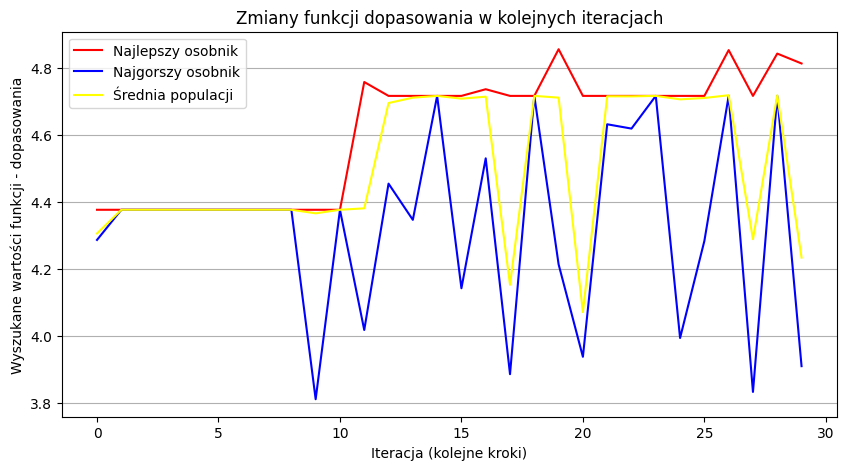

In [ ]:
# Główna pętla algorytmu ewolucyjnego

for generation in range(max_iterns):
  new_population = []

  while len(new_population) < population_size:    # Zapełnianie populacji
    parent1, parent2 = selection(population)      # Selekcja
    child = crossover(parent1, parent2)           # Krzyżowanie
    child = mutation(child)                       # Mutacja
    new_population.append(child)                  # Dodanie nowego osobnika do populacji

  population = np.array(new_population)           # Zapisanie stanu populacji

# Ocena dopasowania
  fit = np.array([f(x) for x in population])      # Tablica wartości funkcji

# Najlepszy osobnik
  best_value = np.max(fit)                        # Najlepsze dopasowanie
  best_x = population[np.argmax(fit)]             # .. i odpowiadający mu argument

# Najgorszy osobnik
  worst_value = np.min(fit)                       # Najgorsze dopasowanie
  worst_x = population[np.argmin(fit)]            # .. i odpowiadający mu argument

# Średnia populacji
  avg = np.mean(fit)

# Ilość najlepszych osobników
  best_count = np.sum(fit == best_value)

# Przechowywanie wyników
  best_fit.append(best_value)
  worst_fit.append(worst_value)
  avg_fit.append(avg)

# Wyprowadzenie wyników

  print(f"Numer pokolenia {generation + 1}")
  print(f"Najlepszy osobnik: f(x) = {best_value} dla x = {best_x}")
  print(f"Najgorszy osobnik: f(x) = {worst_value} dla x = {worst_x}")

  print(f"Średnia populacji: {avg}")
  print(f"Liczba najlepszych osobników: {best_count}\n\n")

# Rozwiązanie optymalne
best_solution = np.max(best_fit)
best_x = population[np.argmax(fit)]
print(f"Najlepsze rozwiązanie: f(x) = {best_solution}")


# Plot
plt.figure(figsize=(10, 5))
plt.plot(range(max_iterns), best_fit, color='red', label='Najlepszy osobnik')
plt.plot(range(max_iterns), worst_fit, color='blue', label='Najgorszy osobnik')
plt.plot(range(max_iterns), avg_fit, color='yellow', label='Średnia populacji')
plt.xlabel('Iteracja (kolejne kroki)')
plt.ylabel('Wyszukane wartości funkcji - dopasowania')
plt.grid(axis = 'y')
plt.legend()
plt.title('Zmiany funkcji dopasowania w kolejnych iteracjach')
plt.show()

###**Zad. 2.** Kod z poprzedniego zadania zmień tak, aby zweryfikować strategię selekcji metodą koła ruletki. Przeanalizuj zmiany wartości na wykresie w kolejnych pokoleniach. Na końcu, w komórce tekstowej, przedstaw wnioski wynikające z porównania modelu z poprzednim.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Definicja funkcji zadanej f(x)
def f(x):
  return x + np.abs(np.sin(32*x))

# Parametry inicjacji algorytmu ewolucyjnego
x_min, x_max = 0, 4             # Zakres dziedziny
population_size = 70            # Liczność populacji
max_iterns = 30                 # Liczba iteracji
mutation_rate = 0.01            # Wskaźnik szybkości mutacji
crossover_rate = 0.7            # Wskaźnik szybkości krzyżowania

# Definicja zmiennych pomocniczych - tablic dopasowania w kolejnych pokoleniach
best_fit = []
worst_fit = []
avg_fit = []

# Definicja populacji
population = np.random.uniform(0, 4, population_size)   # Losowanie osobników

In [ ]:
def roulette_selection(population):
  fit = np.array([f(x) for x in population]) # Funkcja celu (dopasowania)
  total_fit = np.sum(fit)                       # Suma dopasowań
  probabilities = fit / total_fit               # Udział w puli osobników
   # Wybór dwóch osobników z uwzględnieniem prawdopodobieństwa
  indexes = np.random.choice(np.arange(len(population)), size = 2, p = probabilities)
  print(f"Tablica przystosowania = {fit}  \nWybrane indeksy: {indexes} ")
  return population[indexes]

Selekcja metodą ruletki opiera się na wyborze losowych osobników, gdzie największe szansę na reprodukcję mają osobniki najlepiej przystosowane. Jednak te potencjalnie słabsze też mają jakieś szanse - zależnie od stopnia przystosowania. Ogólniej - szansę na reprodukcję ma każdy osobnik, jednak tym mniejszą im słabiej jest przystosowany.

Nazwa "ruletka" odnosi się do sposobu wyłaniania zwycięzców. Można to zobrazować, jako koło ruletki, gdzie najwięcej pól mają najsilniejsi, a im słabsi tym tych pól mają mniej. Zatem prawdopodobieństwo wylosowania jest takie jak ilość pól na kole dla każdego.

Implementacja metody opiera się właśnie na prawdopodobieństwie obliczanym dla każdego osobnika, w następujący sposób:

1. Wyliczamy funkcję celu dla wszystkich osobników (fit)
2. Wyliczamy sumę wszystkich dopasowań z listy (total_fit)
3. Wyliczamy tablicę prawdopodobieństw dla wszystkich osobników (probabilities)
4. Losujemy dwóch przedstawicieli (dwa indeksy) z populacji z określonym prawdopodobieństwem
5. Zwracamy dwie  wartości z wylosowanych indeksów

Jak widać algorytm nawiązuje wyraźnie do warunków zagadnienia gry koła ruletki.

In [ ]:
# Krzyżowanie cech/genów dla 2-ch osobnoków
def crossover(parent1, parent2):
  if np.random.random() < crossover_rate:       # Prawdopodobieństwo krzyżowania
    return (parent1 + parent2) / 2              # Średnia jeśli skrzyżowano
  return parent1                              # Cechy pierwszego w całości

# Mutowanie cech - zmiana wartości (względnie małego rzędu)
def mutation(x):
  if np.random.random() < mutation_rate:         # Prawdopodobieństwo mutacji
    x = x + (np.random.uniform(-0.1, 0.1))       # Mutowanie wartością z przedziału [-0.1, 0.1]
    x = np.clip(x, x_min, x_max)                 # Strażnnik wartości granicznych
  return x                                       # Zwraca nowego osobnika

Numer pokolenia 1
Najlepszy osobnik: f(x) = 4.86988788042229 dla x = 3.882962259235062
Najgorszy osobnik: f(x) = 4.015671790850897 dla x = 3.9241259999838025
Średnia populacji: 4.306419447705082
Liczba najlepszych osobników: 23


Numer pokolenia 2
Najlepszy osobnik: f(x) = 4.86988788042229 dla x = 3.882962259235062
Najgorszy osobnik: f(x) = 4.677508583795448 dla x = 3.8587902747528116
Średnia populacji: 4.8671396047561934
Liczba najlepszych osobników: 69


Numer pokolenia 3
Najlepszy osobnik: f(x) = 4.86988788042229 dla x = 3.882962259235062
Najgorszy osobnik: f(x) = 4.258894230697267 dla x = 3.8144227926498737
Średnia populacji: 4.857389050753516
Liczba najlepszych osobników: 68


Numer pokolenia 4
Najlepszy osobnik: f(x) = 4.86988788042229 dla x = 3.882962259235062
Najgorszy osobnik: f(x) = 4.504646491453718 dla x = 3.9455319852528525
Średnia populacji: 4.864670146294169
Liczba najlepszych osobników: 69


Numer pokolenia 5
Najlepszy osobnik: f(x) = 4.86988788042229 dla x = 3.88296225

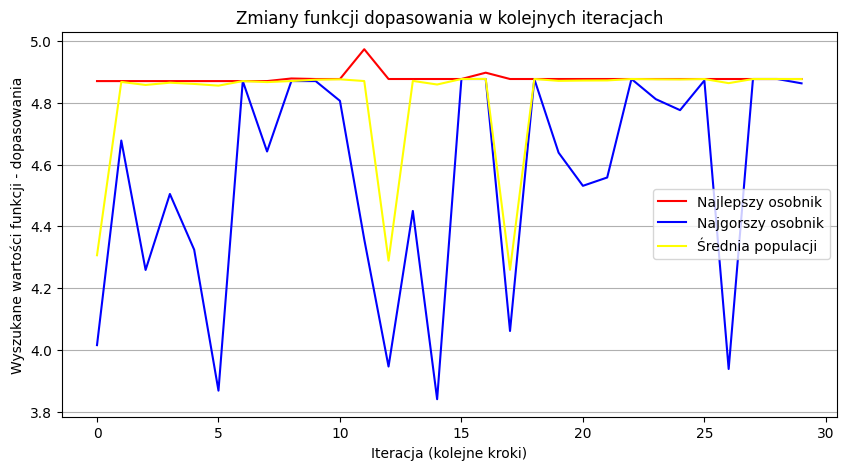

In [ ]:
# Główna pętla algorytmu ewolucyjnego

for generation in range(max_iterns):
  new_population = []

  while len(new_population) < population_size:    # Zapełnianie populacji
    parent1, parent2 = selection(population)      # Selekcja
    child = crossover(parent1, parent2)           # Krzyżowanie
    child = mutation(child)                       # Mutacja
    new_population.append(child)                  # Dodanie nowego osobnika do populacji

  population = np.array(new_population)           # Zapisanie stanu populacji

# Ocena dopasowania
  fit = np.array([f(x) for x in population])      # Tablica wartości funkcji

# Najlepszy osobnik
  best_value = np.max(fit)                        # Najlepsze dopasowanie
  best_x = population[np.argmax(fit)]             # .. i odpowiadający mu argument

# Najgorszy osobnik
  worst_value = np.min(fit)                       # Najgorsze dopasowanie
  worst_x = population[np.argmin(fit)]            # .. i odpowiadający mu argument

# Średnia populacji
  avg = np.mean(fit)

# Ilość najlepszych osobników
  best_count = np.sum(fit == best_value)

# Przechowywanie wyników
  best_fit.append(best_value)
  worst_fit.append(worst_value)
  avg_fit.append(avg)

# Wyprowadzenie wyników

  print(f"Numer pokolenia {generation + 1}")
  print(f"Najlepszy osobnik: f(x) = {best_value} dla x = {best_x}")
  print(f"Najgorszy osobnik: f(x) = {worst_value} dla x = {worst_x}")

  print(f"Średnia populacji: {avg}")
  print(f"Liczba najlepszych osobników: {best_count}\n\n")

# Rozwiązanie optymalne
best_solution = np.max(best_fit)
best_x = population[np.argmax(fit)]
print(f"Najlepsze rozwiązanie: f(x) = {best_solution}")


# Plot
plt.figure(figsize=(10, 5))
plt.plot(range(max_iterns), best_fit, color='red', label='Najlepszy osobnik')
plt.plot(range(max_iterns), worst_fit, color='blue', label='Najgorszy osobnik')
plt.plot(range(max_iterns), avg_fit, color='yellow', label='Średnia populacji')
plt.xlabel('Iteracja (kolejne kroki)')
plt.ylabel('Wyszukane wartości funkcji - dopasowania')
plt.grid(axis = 'y')
plt.legend()
plt.title('Zmiany funkcji dopasowania w kolejnych iteracjach')
plt.show()

Co do zasady trudno wskazać wyraźne różnice pomiędzy modelem z selekcją elitarną i ruletkową. Pierwszy promuje najlepsze rozwiązania od samego początku poszukiwań funkcji celu. Drugi wprowadza dość losowy sposób, co może być potrzebne w trudniejszych zagadnieniach, gdzie może dojść do utraty różnorodności. Na pewno bardzo dużą rolę  w obu metodach pełnią parametry (szczególnie) wielkość populacji oraz liczba obserwowanych pokoleń. Może też w metodzie ruletkowej bardziej stabilne na wykresie są przedstawiciele najgorzej dopasowani, ale to kwestia losowa (nie koniecznie powtarzalna).

###**Zad. 3.** Kod z poprzedniego zadania zmień tak, aby zweryfikować strategię selekcji metodą turniejową. Przeanalizuj zmiany wartości na wykresie w kolejnych pokoleniach. Na końcu, w komórce tekstowej, przedstaw wnioski wynikające z porównania modelu z poprzednim.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Definicja funkcji zadanej f(x)
def f(x):
  return x + np.abs(np.sin(32*x))

# Parametry inicjacji algorytmu ewolucyjnego
x_min, x_max = 0, 4             # Zakres dziedziny
population_size = 70            # Liczność populacji
max_iterns = 30                 # Liczba iteracji
mutation_rate = 0.01            # Wskaźnik szybkości mutacji
crossover_rate = 0.7            # Wskaźnik szybkości krzyżowania

tour_size = 6

# Definicja zmiennych pomocniczych - tablic dopasowania w kolejnych pokoleniach
best_fit = []
worst_fit = []
avg_fit = []

# Definicja populacji
population = np.random.uniform(0, 4, population_size)   # Losowanie osobników

In [ ]:
# Selekcja najlepiej przystosowanych osobników (definicja funkcji selekcji turniejowej)
def tour_selection(population):

  select = []                             # Inicjacja tebeli wyniku
  for _ in range(2):                      # Dwie iteracje
    tour = np.random.choice(population, tour_size, replace = False)  # Wybranie zawodników
    select.append(max(tour, key = f))     # Określenie lepszego (zwycięzcy) wg. funkji f(x)
  return select

W tej metodzie selekcji algorytm organizuje rodzaj turnieju, gdzie losujemy przedstawicieli i wystawiamy ich do rywalizacji. A wygrywa najlepszy i przekazuje swój gen.

W tym przypadku losujemy z puli populacji dwóch zawodników bez powtórzeń i przekazujemy do zmiennej (tour). Następnie wybierany jest osobnik z najwyższą wartością funkcji f(x) i dodawany do listy select. Ten fragment kodu wykonujemy dwukrotnie. Zwrócenie tablicy (select) daje w wyniku dwóch turniejowych osobników.

In [ ]:
# Krzyżowanie cech/genów dla 2-ch osobnoków
def crossover(parent1, parent2):
  if np.random.random() < crossover_rate:       # Prawdopodobieństwo krzyżowania
    return (parent1 + parent2) / 2              # Średnia jeśli skrzyżowano
  return parent1                              # Cechy pierwszego w całości

# Mutowanie cech - zmiana wartości (względnie małego rzędu)
def mutation(x):
  if np.random.random() < mutation_rate:         # Prawdopodobieństwo mutacji
    x = x + (np.random.uniform(-0.1, 0.1))       # Mutowanie wartością z przedziału [-0.1, 0.1]
    x = np.clip(x, x_min, x_max)                 # Strażnnik wartości granicznych
  return x

Numer pokolenia 1
Najlepszy osobnik: f(x) = 4.8569240758698555 dla x = 3.8853757239841213
Najgorszy osobnik: f(x) = 4.779975794666003 dla x = 3.7813919881267704
Średnia populacji: 4.830541808028536
Liczba najlepszych osobników: 46


Numer pokolenia 2
Najlepszy osobnik: f(x) = 4.8569240758698555 dla x = 3.8853757239841213
Najgorszy osobnik: f(x) = 4.8569240758698555 dla x = 3.8853757239841213
Średnia populacji: 4.856924075869856
Liczba najlepszych osobników: 70


Numer pokolenia 3
Najlepszy osobnik: f(x) = 4.8569240758698555 dla x = 3.8853757239841213
Najgorszy osobnik: f(x) = 4.129997754630713 dla x = 3.8380734879382397
Średnia populacji: 4.843972950968231
Liczba najlepszych osobników: 68


Numer pokolenia 4
Najlepszy osobnik: f(x) = 4.8569240758698555 dla x = 3.8853757239841213
Najgorszy osobnik: f(x) = 4.525433807386285 dla x = 3.9462931357161604
Średnia populacji: 4.852188500605806
Liczba najlepszych osobników: 69


Numer pokolenia 5
Najlepszy osobnik: f(x) = 4.8569240758698555 dla 

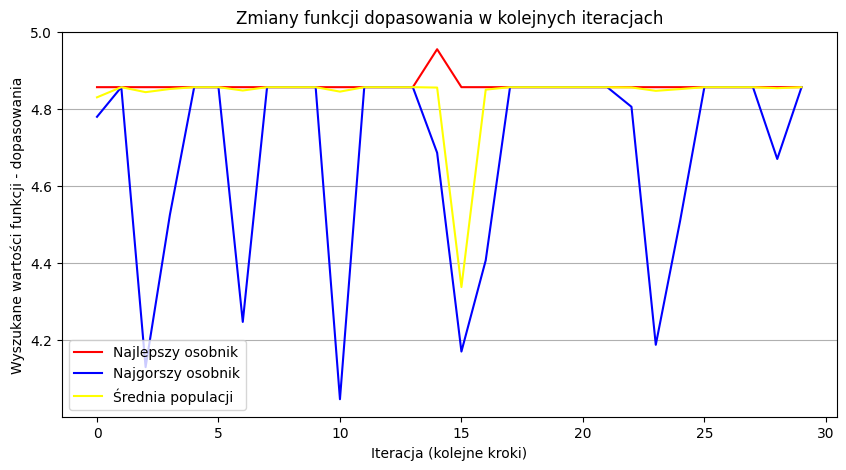

In [ ]:
# Główna pętla algorytmu ewolucyjnego

for generation in range(max_iterns):
  new_population = []

  while len(new_population) < population_size:    # Zapełnianie populacji
    parent1, parent2 = selection(population)      # Selekcja
    child = crossover(parent1, parent2)           # Krzyżowanie
    child = mutation(child)                       # Mutacja
    new_population.append(child)                  # Dodanie nowego osobnika do populacji

  population = np.array(new_population)           # Zapisanie stanu populacji

# Ocena dopasowania
  fit = np.array([f(x) for x in population])      # Tablica wartości funkcji

# Najlepszy osobnik
  best_value = np.max(fit)                        # Najlepsze dopasowanie
  best_x = population[np.argmax(fit)]             # .. i odpowiadający mu argument

# Najgorszy osobnik
  worst_value = np.min(fit)                       # Najgorsze dopasowanie
  worst_x = population[np.argmin(fit)]            # .. i odpowiadający mu argument

# Średnia populacji
  avg = np.mean(fit)

# Ilość najlepszych osobników
  best_count = np.sum(fit == best_value)

# Przechowywanie wyników
  best_fit.append(best_value)
  worst_fit.append(worst_value)
  avg_fit.append(avg)

# Wyprowadzenie wyników

  print(f"Numer pokolenia {generation + 1}")
  print(f"Najlepszy osobnik: f(x) = {best_value} dla x = {best_x}")
  print(f"Najgorszy osobnik: f(x) = {worst_value} dla x = {worst_x}")

  print(f"Średnia populacji: {avg}")
  print(f"Liczba najlepszych osobników: {best_count}\n\n")

# Rozwiązanie optymalne
best_solution = np.max(best_fit)
best_x = population[np.argmax(fit)]
print(f"Najlepsze rozwiązanie: f(x) = {best_solution}")


# Plot
plt.figure(figsize=(10, 5))
plt.plot(range(max_iterns), best_fit, color='red', label='Najlepszy osobnik')
plt.plot(range(max_iterns), worst_fit, color='blue', label='Najgorszy osobnik')
plt.plot(range(max_iterns), avg_fit, color='yellow', label='Średnia populacji')
plt.xlabel('Iteracja (kolejne kroki)')
plt.ylabel('Wyszukane wartości funkcji - dopasowania')
plt.grid(axis = 'y')
plt.legend()
plt.title('Zmiany funkcji dopasowania w kolejnych iteracjach')
plt.show()

Jeśli chodzi o dyskusję wyniku w metodzie ruletkowej i turniejowej, ten drugi model jest zdecydowanie mniej stabilny, są wyraźne wachania wartości pomiędzy pokoleniami dla najsłabszych dopasowań. W tym modelu ustawiłem też większą ilość tur w turnieju (6), co poprawia jakość wyniku. Jednak w odróżnieniu od modelu ruletkowego występują niewielkie korekty najlepszego rozwiązania pomiędzy pokoleniami.

###**Zad. 4.** Kod z poprzedniego zadania zmień tak, aby zmienić sposób kodowania osobników do postaci binarnej. Zastanów się też nad zmianą sposobu krzyżowania (wymiana genów rodziców na losowo wybranej pozycji) i mutacji osobników. Przeanalizuj zmiany wartości na wykresie w kolejnych pokoleniach. Na końcu, w komórce tekstowej, przedstaw wnioski wynikające z porównania modelu z poprzednim.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Funkcja celu
def f(x):
    return x + np.abs(np.sin(32 * x))

# Parametry algorytmu genetycznego
population_size = 70	        #	Rozmiar populacji
max_iterns = 30	        #	Liczba iteracji (pokoleń)
mutation_rate = 0.01    # Prawdopodobieństwo mutacji
crossover_rate = 0.7    # Prawdopodobieństwo krzyżowania
x_min, x_max = 0, 4	    # Zakres wartości x
tournament_size = 2	    # Liczba osobników biorących udział w turnieju
bit_length = 16          # Długość reprezentacji binarnej



# Listy do przechowywania statystyk dla każdego pokolenia
best_fit = []
worst_fit = []
avg_fit = []

In [ ]:
# Funkcja konwertująca - liczba zmiennoprzecinkowa na reprezentację binarną

def f2b(x):
    normalized = (x - x_min) / (x_max - x_min)      # Zawężenie do zakresu [0,1] (normalizacja)
    int_no = int(normalized * (2**bit_length - 1))  # Całkowity numer podrzedziału
    binary = np.array([int(i) for i in format(int_no, f'0{bit_length}b')], dtype=int)  # Zamiana Int na tablicę binarną
    return binary


# Funkcja konwertująca - reprezentacja binarna na liczbę zmiennoprzecinkową

def b2f(binary):
    bin_str = ''.join(map(str, binary))  # Połączenie tablicy (binarnej) w String
    int_no = int(bin_str, 2)             # Konwersja z postaci binarnej do całkowitej
    normalized = int_no / (2**bit_length - 1)   # Normalizacja liczby do przedziału [0,1]
    origin = x_min + normalized * (x_max - x_min) # Odzyskanie przybliżenia pierwotnej wartości
    return origin

# Funkcja losująca binarnego osobnika

#def create():
#    return ''.join(np.random.choice(['0', '1']) for _ in range(bit_length))

# Definiowanie populacji
# population = [create() for _ in range(population_size)]



# Inicjalizacja populacji
population = np.random.uniform(x_min, x_max, population_size)
population_bin = np.array([f2b(x) for x in population])

In [ ]:
# Funkcja selekcji - selekcja turniejowa
def selection(population_bin):
    # Losujemy kilku osobników z populacji (turniej)
    selected_indices = np.random.choice(len(population_bin), tournament_size, replace=False)
    selected_individuals = population_bin[selected_indices]
    # Obliczamy fitness dla wybranych osobników
    fitness = np.array([f(b2f(x)) for x in selected_individuals])
    # Zwracamy najlepszego osobnika (o najwyższym fitness)
    best_idx = np.argmax(fitness)
    return selected_individuals[best_idx]


# Krzyżowanie - wymiana genów dwóch osobników
def crossover(parent1, parent2):
    if np.random.rand() < crossover_rate:
        # Krzyżowanie jednolite (losowe wybieranie bitów z rodziców)
        mask = np.random.rand(len(parent1)) < 0.5
        child = np.where(mask, parent1, parent2)
        return child
    return parent1

# Mutacja - drobna zmiana bitu
def mutation(individual):
    if np.random.rand() < mutation_rate:
        # Losujemy pozycję bitu do zmiany
        mutation_point = np.random.randint(len(individual))
        individual[mutation_point] = 1 - individual[mutation_point] # Zmiana bitu
    return individual

Funkcja turniejowej selekcji została już przedstawiona w zadaniu poprzednim.  Różnicą jest sposób wyznaczania tablicy dopasowań (fitness) do turnieju między wylosowanymi osobnikami. Wykorzystywana jest funkcja konwersji z postaci binarnej do zmiennoprzecinkowej zdefiniowana jako b2f(), a wyliczenie f(x) przyjmuje wtedy postać - f(b2f(x)).

Krzyżowanie z losowym wybieraniem bitów wśród rodziców, nazywamy czasem metodą krzyżowania z maską. Zostaje wyznaczona maska bitów (o długości rodziców - len(parent1). Losowe zera i jedynki porównujemy z wartościę 0.5 co w efekcie daje tablicę losowo ustawionych True ora False (mniejsze lub większe od 0.5).

Numer pokolenia 1
Najlepszy osobnik: f(x) = 4.975382817168072 dla x = 3.9785763332570383
Najgorszy osobnik: f(x) = 1.2058142782141203 dla x = 1.1772030212863356
Średnia populacji: 3.4136143964485757
Numer pokolenia 2
Najlepszy osobnik: f(x) = 4.884413632992244 dla x = 3.963561455710689
Najgorszy osobnik: f(x) = 1.787601828794453 dla x = 0.8258182650492103
Średnia populacji: 3.9015073364951345
Numer pokolenia 3
Najlepszy osobnik: f(x) = 4.888482633483951 dla x = 3.963866636148623
Najgorszy osobnik: f(x) = 3.114662223078213 dla x = 2.8552681773098345
Średnia populacji: 4.294943174218683
Numer pokolenia 4
Najlepszy osobnik: f(x) = 4.846455368805101 dla x = 3.870969710841535
Najgorszy osobnik: f(x) = 3.419224260078342 dla x = 3.335317006179904
Średnia populacji: 4.473138450674356
Numer pokolenia 5
Najlepszy osobnik: f(x) = 4.915034409870792 dla x = 3.988097962920577
Najgorszy osobnik: f(x) = 3.8673391231015195 dla x = 3.6248111696040284
Średnia populacji: 4.547492521785742
Numer pokolenia 

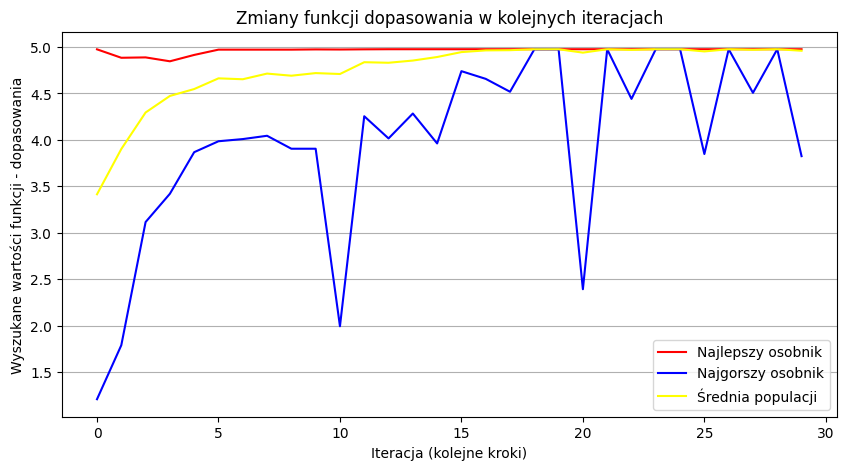

In [ ]:
# Główna pętla algorytmu ewolucyjnego

for generation in range(max_iterns):
  new_population_bin = []

  while len(new_population_bin) < population_size:    # Zapełnianie populacji
    parent1_bin = selection(population_bin)
    parent2_bin = selection(population_bin)      # Selekcja
    child_bin = crossover(parent1_bin, parent2_bin)           # Krzyżowanie
    child_bin = mutation(child_bin)                       # Mutacja
    new_population_bin.append(child_bin)                  # Dodanie nowego osobnika do populacji

  population_bin = np.array(new_population_bin)           # Zapisanie stanu populacji

  # Definicja populacji

  population = np.array([b2f(id) for id in population_bin])

  # Ocena dopasowania
  fit = np.array([f(x) for x in population])      # Tablica wartości funkcji

  # Najlepszy osobnik
  best_value = np.max(fit)                        # Najlepsze dopasowanie
  best_x = population[np.argmax(fit)]             # .. i odpowiadający mu argument

  # Najgorszy osobnik
  worst_value = np.min(fit)                       # Najgorsze dopasowanie
  worst_x = population[np.argmin(fit)]            # .. i odpowiadający mu argument

  # Średnia populacji
  avg = np.mean(fit)


  # Przechowywanie wyników
  best_fit.append(best_value)
  worst_fit.append(worst_value)
  avg_fit.append(avg)

  # Wyprowadzenie wyników

  print(f"Numer pokolenia {generation + 1}")
  print(f"Najlepszy osobnik: f(x) = {best_value} dla x = {best_x}")
  print(f"Najgorszy osobnik: f(x) = {worst_value} dla x = {worst_x}")

  print(f"Średnia populacji: {avg}")

# Rozwiązanie optymalne
best_solution = np.max(best_fit)
best_x = population[np.argmax(fit)]
print(f"Najlepsze rozwiązanie: f(x) = {best_solution}")


# Plot
plt.figure(figsize=(10, 5))
plt.plot(range(max_iterns), best_fit, color='red', label='Najlepszy osobnik')
plt.plot(range(max_iterns), worst_fit, color='blue', label='Najgorszy osobnik')
plt.plot(range(max_iterns), avg_fit, color='yellow', label='Średnia populacji')
plt.xlabel('Iteracja (kolejne kroki)')
plt.ylabel('Wyszukane wartości funkcji - dopasowania')
plt.grid(axis = 'y')
plt.legend()
plt.title('Zmiany funkcji dopasowania w kolejnych iteracjach')
plt.show()

Zmieniając sposób kodowania osobników do postaci binarnej można by powiedzieć, iż stawka osobników jest zdecydowanie bardziej wyrównana. W rzeczywistości nie różni się zbytnio od poprzednich (ewolucyjnych metod), jednak przy każdej próbie obliczeń algorytm zaczyna przeszukiwanie od niskich wartości, co jest widoczne na wykresie, szczególnie dla najsłabiej przystosowanych.

###**Zad. 5.** Kod z poprzedniego zadania zmień tak, aby zmienić sposób krzyżowania osobników (dziecko (child) składa się z części parent1 do punktu krzyżowania oraz części parent2 od punktu krzyżowania do końca). Przeanalizuj zmiany wartości na wykresie w kolejnych pokoleniach. Na końcu, w komórce tekstowej, przedstaw wnioski wynikające z porównania modelu z poprzednim.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Funkcja celu
def f(x):
    return x + np.abs(np.sin(32 * x))

# Parametry algorytmu genetycznego
population_size = 70	        #	Rozmiar populacji
max_iterns = 30	        #	Liczba iteracji (pokoleń)
mutation_rate = 0.01    # Prawdopodobieństwo mutacji
crossover_rate = 0.7    # Prawdopodobieństwo krzyżowania
x_min, x_max = 0, 4	    # Zakres wartości x
tournament_size = 2	    # Liczba osobników biorących udział w turnieju
bit_length = 16         # Długość reprezentacji binarnej



# Listy do przechowywania statystyk dla każdego pokolenia
best_fit = []
worst_fit = []
avg_fit = []

In [ ]:
# Funkcja konwertująca - liczba zmiennoprzecinkowa na reprezentację binarną

def f2b(x):
    normalized = (x - x_min) / (x_max - x_min)      # Zawężenie do zakresu [0,1] (normalizacja)
    int_no = int(normalized * (2**bit_length - 1))  # Całkowity numer podrzedziału
    binary = np.array([int(i) for i in format(int_no, f'0{bit_length}b')], dtype=int)  # Zamiana Int na tablicę binarną
    return binary


# Funkcja konwertująca - reprezentacja binarna na liczbę zmiennoprzecinkową

def b2f(binary):
    bin_str = ''.join(map(str, binary))  # Połączenie tablicy (binarnej) w String
    int_no = int(bin_str, 2)             # Konwersja z postaci binarnej do całkowitej
    normalized = int_no / (2**bit_length - 1)   # Normalizacja liczby do przedziału [0,1]
    origin = x_min + normalized * (x_max - x_min) # Odzyskanie przybliżenia pierwotnej wartości
    return origin

# Funkcja losująca binarnego osobnika

def create():
    return ''.join(np.random.choice(['0', '1']) for _ in range(bit_length))

# Inicjalizacja populacji
population = np.random.uniform(x_min, x_max, population_size)
population_bin = np.array([f2b(x) for x in population])

In [ ]:
# Funkcja selekcji - selekcja turniejowa
def selection(population_bin):
    # Losujemy kilku osobników z populacji (turniej)
    selected_indices = np.random.choice(len(population_bin), tournament_size, replace=False)
    selected_individuals = population_bin[selected_indices]
    # Obliczamy fitness dla wybranych osobników
    fitness = np.array([f(b2f(ind)) for ind in selected_individuals])
    # Zwracamy najlepszego osobnika (o najwyższym fitness)
    best_idx = np.argmax(fitness)
    return selected_individuals[best_idx]


# Krzyżowanie - przekazanie genów z dwóch osobników
def crossover(parent1, parent2):
    # Wybierz punkt cięcia
    point = random.randint(1, bit_length - 1)
    # Tworzymy dziecko, łącząc część od rodzica 1 i część od rodzica 2
    child = np.concatenate((parent1[:point], parent2[point:]))
    return child

# Mutacja - drobna zmiana bitu
def mutation(individual):
    if np.random.rand() < mutation_rate:
        # Losujemy pozycję bitu do zmiany
        mutation_point = np.random.randint(len(individual))
        individual[mutation_point] = 1 - individual[mutation_point] # Zmiana bitu
    return individual

Użyto tu krzyżowania zgodnie z poleceniem. Wybieramy punkt przecięcia genów na pozycji pomiędzy pierwszym a ostatnim polem (bez wartości skrajnych) i zapisujemu jako (point). Następnie dokonujemy konkatenacji genów - składając z dwóch części. Przepisujemy pierwszą część genów z pozycji od od 0 do point z pierwszego rodzica oraz drugą część genu od pozycji point do bit_length (tzn. do końca genu) drugiego rodzica. Tak wyznaczonego potomka zwracamy funkcją, jako wynik działania.

Numer pokolenia 1
Najlepszy osobnik: f(x) = 4.87803891356564 dla x = 3.878049897001602
Najgorszy osobnik: f(x) = 0.9910333463813344 dla x = 0.1305561913481346
Średnia populacji: 3.1626420788627527
Numer pokolenia 2
Najlepszy osobnik: f(x) = 4.961217093424814 dla x = 3.9825436789501794
Najgorszy osobnik: f(x) = 1.3402842072656247 dla x = 0.4570382238498512
Średnia populacji: 3.674745810954864
Numer pokolenia 3
Najlepszy osobnik: f(x) = 4.973503992203738 dla x = 3.9746089875638972
Najgorszy osobnik: f(x) = 2.664882693680861 dla x = 1.708766308079652
Średnia populacji: 4.172981323760875
Numer pokolenia 4
Najlepszy osobnik: f(x) = 4.973503992203738 dla x = 3.9746089875638972
Najgorszy osobnik: f(x) = 3.1751245191571464 dla x = 2.3846799420157168
Średnia populacji: 4.423273015900648
Numer pokolenia 5
Najlepszy osobnik: f(x) = 4.973503992203738 dla x = 3.9746089875638972
Najgorszy osobnik: f(x) = 3.909605077776284 dla x = 3.3181658655680173
Średnia populacji: 4.682923676989397
Numer pokoleni

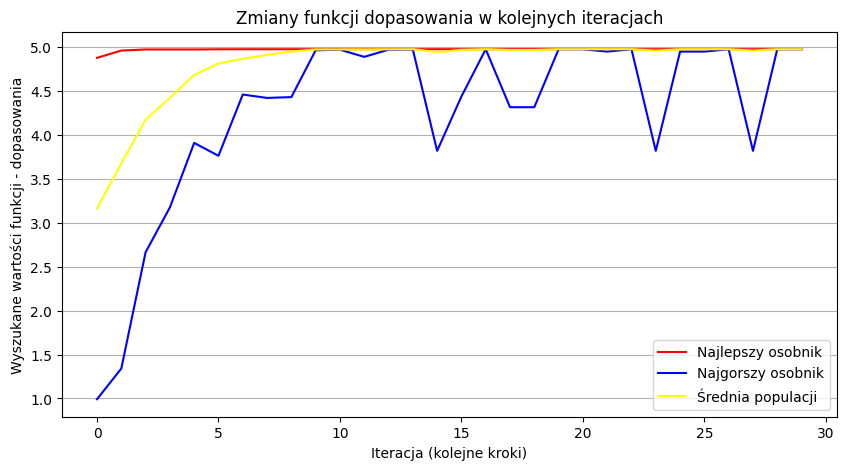

In [ ]:
# Główna pętla algorytmu ewolucyjnego

for generation in range(max_iterns):
  new_population_bin = []

  while len(new_population_bin) < population_size:    # Zapełnianie populacji
    parent1_bin = selection(population_bin)
    parent2_bin = selection(population_bin)      # Selekcja
    child_bin = crossover(parent1_bin, parent2_bin)           # Krzyżowanie
    child_bin = mutation(child_bin)                       # Mutacja
    new_population_bin.append(child_bin)                  # Dodanie nowego osobnika do populacji

  population_bin = np.array(new_population_bin)           # Zapisanie stanu populacji

  # Definicja populacji

  population = np.array([b2f(id) for id in population_bin])

  # Ocena dopasowania
  fit = np.array([f(x) for x in population])      # Tablica wartości funkcji

  # Najlepszy osobnik
  best_value = np.max(fit)                        # Najlepsze dopasowanie
  best_x = population[np.argmax(fit)]             # .. i odpowiadający mu argument

  # Najgorszy osobnik
  worst_value = np.min(fit)                       # Najgorsze dopasowanie
  worst_x = population[np.argmin(fit)]            # .. i odpowiadający mu argument

  # Średnia populacji
  avg = np.mean(fit)


  # Przechowywanie wyników
  best_fit.append(best_value)
  worst_fit.append(worst_value)
  avg_fit.append(avg)

  # Wyprowadzenie wyników

  print(f"Numer pokolenia {generation + 1}")
  print(f"Najlepszy osobnik: f(x) = {best_value} dla x = {best_x}")
  print(f"Najgorszy osobnik: f(x) = {worst_value} dla x = {worst_x}")

  print(f"Średnia populacji: {avg}")

# Rozwiązanie optymalne
best_solution = np.max(best_fit)
best_x = population[np.argmax(fit)]
print(f"Najlepsze rozwiązanie: f(x) = {best_solution}")


# Plot
plt.figure(figsize=(10, 5))
plt.plot(range(max_iterns), best_fit, color='red', label='Najlepszy osobnik')
plt.plot(range(max_iterns), worst_fit, color='blue', label='Najgorszy osobnik')
plt.plot(range(max_iterns), avg_fit, color='yellow', label='Średnia populacji')
plt.xlabel('Iteracja (kolejne kroki)')
plt.ylabel('Wyszukane wartości funkcji - dopasowania')
plt.grid(axis = 'y')
plt.legend()
plt.title('Zmiany funkcji dopasowania w kolejnych iteracjach')
plt.show()

W porównaniu metod z zadania 4 i zadania 5, które różnią się metodą krzyżowania, trudno wykazać wyraźne różnice w wyniku ich działania. Podobnie jak poprzednio, tak i w tym zadaniu, algorytm zaczyna obliczenia od niskich wartości, podobnie najlepszy wynik zostaje wcześnie ustalony, tylko najgorszy wynik jest bardziej stabilny.

###**Zad. 6.** Kod z poprzedniego zadania zmień tak, aby zmienić strategię selekcji na koło ruletki. Przeanalizuj zmiany wartości na wykresie w kolejnych pokoleniach. Na końcu, w komórce tekstowej, przedstaw wnioski wynikające z porównania modelu z poprzednim.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Funkcja celu
def f(x):
    return x + np.abs(np.sin(32 * x))

# Parametry algorytmu genetycznego
population_size = 70	        #	Rozmiar populacji
max_iterns = 30	        #	Liczba iteracji (pokoleń)
mutation_rate = 0.01    # Prawdopodobieństwo mutacji
crossover_rate = 0.7    # Prawdopodobieństwo krzyżowania
x_min, x_max = 0, 4	    # Zakres wartości x
tournament_size = 2	    # Liczba osobników biorących udział w turnieju
bit_length = 16         # Długość reprezentacji binarnej



# Listy do przechowywania statystyk dla każdego pokolenia
best_fit = []
worst_fit = []
avg_fit = []

In [ ]:
def f2b(x):
    normalized = (x - x_min) / (x_max - x_min)      # Zawężenie do zakresu [0,1] (normalizacja)
    int_no = int(normalized * (2**bit_length - 1))  # Całkowity numer podrzedziału
    binary = np.array([int(i) for i in format(int_no, f'0{bit_length}b')], dtype=int)  # Zamiana Int na tablicę binarną
    return binary


# Funkcja konwertująca - reprezentacja binarna na liczbę zmiennoprzecinkową

def b2f(binary):
    bin_str = ''.join(map(str, binary))  # Połączenie tablicy (binarnej) w String
    int_no = int(bin_str, 2)             # Konwersja z postaci binarnej do całkowitej
    normalized = int_no / (2**bit_length - 1)   # Normalizacja liczby do przedziału [0,1]
    origin = x_min + normalized * (x_max - x_min) # Odzyskanie przybliżenia pierwotnej wartości
    return origin

# Funkcja losująca binarnego osobnika

def create():
    return ''.join(np.random.choice(['0', '1']) for _ in range(bit_length))

# Definiowanie populacji
# population = [create() for _ in range(population_size)]



# Inicjalizacja populacji
population = np.random.uniform(x_min, x_max, population_size)
population_bin = np.array([f2b(x) for x in population])

In [ ]:
# Funkcja selekcji - selekcja ruletkowa

def selection(population_bin):
  fit = np.array([f(b2f(x)) for x in population_bin]) # Funkcja celu (dopasowania)
  total_fit = np.sum(fit)                       # Suma dopasowań
  if total_fit == 0:
    probabilities = np.ones(len(fit)) / len(fit)
  else:
    probabilities = fit / total_fit             # Udział w puli osobników
  # Wybór dwóch osobników z uwzględnieniem prawdopodobieństwa
  indexes = np.random.choice(np.arange(len(population_bin)), size = 2, p = probabilities)
  return population_bin[indexes]


# Krzyżowanie - wymiana genów dwóch osobników

def crossover(parent1, parent2):
    # Wybierz punkt cięcia
    point = random.randint(1, bit_length - 1)
    # Tworzymy dziecko, łącząc część od rodzica 1 i od rodzica 2
    child = np.concatenate((parent1[:point], parent2[point:]))
    return child

# Mutacja - drobna zmiana bitu
def mutation(individual):
    if np.random.rand() < mutation_rate:
        # Losujemy pozycję bitu do zmiany
        mutation_point = np.random.randint(len(individual))
        individual[mutation_point] = 1 - individual[mutation_point] # Zmiana bitu
    return individual

Metoda selekcji ruletkowej dla obliczeń ewolucyjnych została opisana w zadaniu 2. W tym zadaniu została zmodyfikowana tak, aby można było zastosować ją do obliczeń algorytmów genetycznych.

Tworzymy listę wyników wywołań f(b2f(x)) dla każdego x w population_bin.
Co oznacza, że dla każdego elementu z populacji binarnej (chromosomu), najpierw zamienia go na wartość liczbową (float), a następnie ocenia przy użyciu funkcji celu f(). Fragment z użyciem bloku if - else zapobiega sytuacji, w której suma wszystkich genów osobnika jest równa zero. Wtedy zamiast przydzielać odpowiednio prawdopodobieństwa, przypisujemy wszystkim osobnikom równą szansę wyboru (dzielimy pólę na ilość osobników).


Numer pokolenia 1
Najlepszy osobnik: f(x) = 4.515523050808621 dla x = 3.5960021362630656
Najgorszy osobnik: f(x) = 0.29069072372873483 dla x = 0.19330128938735028
Średnia populacji: 2.901097753018279
Numer pokolenia 2
Najlepszy osobnik: f(x) = 4.680249366758677 dla x = 3.680659189745937
Najgorszy osobnik: f(x) = 0.5911315433579053 dla x = 0.3987487602044709
Średnia populacji: 3.297695283923387
Numer pokolenia 3
Najlepszy osobnik: f(x) = 4.876514158829181 dla x = 3.8807965209430075
Najgorszy osobnik: f(x) = 1.3296148074810095 dla x = 0.3499198901350423
Średnia populacji: 3.6501676959673692
Numer pokolenia 4
Najlepszy osobnik: f(x) = 4.857729426464395 dla x = 3.885252155336843
Najgorszy osobnik: f(x) = 1.9708220957269356 dla x = 1.2053406576638437
Średnia populacji: 3.8191176748169857
Numer pokolenia 5
Najlepszy osobnik: f(x) = 4.8642196132427475 dla x = 3.8841535057602807
Najgorszy osobnik: f(x) = 0.83874588178177 dla x = 0.5966887922484169
Średnia populacji: 3.847189931909167
Numer pok

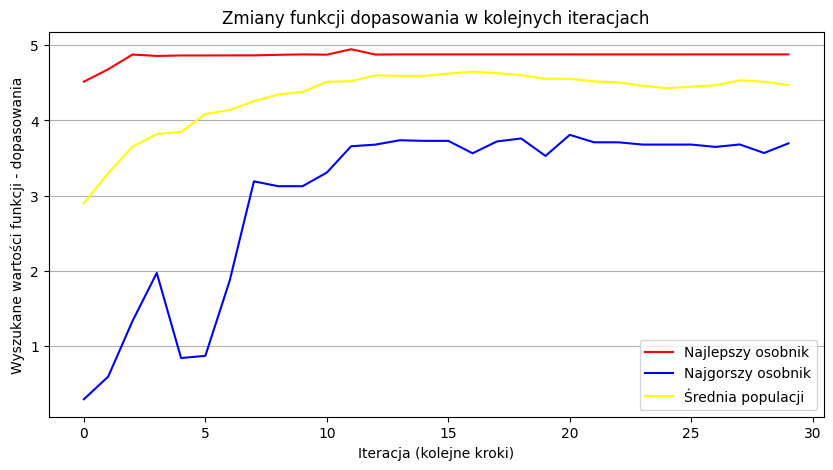

In [ ]:
# Główna pętla algorytmu ewolucyjnego

for generation in range(max_iterns):
  new_population_bin = []

  while len(new_population_bin) < population_size:    # Zapełnianie populacji
    parent1_bin, parent2_bin = selection(population_bin)      # Selekcja
    child_bin = crossover(parent1_bin, parent2_bin)           # Krzyżowanie
    child_bin = mutation(child_bin)                       # Mutacja
    new_population_bin.append(child_bin)                  # Dodanie nowego osobnika do populacji

  population_bin = np.array(new_population_bin)           # Zapisanie stanu populacji

  # Definicja populacji

  population = np.array([b2f(x) for x in population_bin])

  # Ocena dopasowania
  fit = np.array([f(x) for x in population])      # Tablica wartości funkcji

  # Najlepszy osobnik
  best_value = np.max(fit)                        # Najlepsze dopasowanie
  best_x = population[np.argmax(fit)]             # .. i odpowiadający mu argument

  # Najgorszy osobnik
  worst_value = np.min(fit)                       # Najgorsze dopasowanie
  worst_x = population[np.argmin(fit)]            # .. i odpowiadający mu argument

  # Średnia populacji
  avg = np.mean(fit)


  # Przechowywanie wyników
  best_fit.append(best_value)
  worst_fit.append(worst_value)
  avg_fit.append(avg)

  # Wyprowadzenie wyników

  print(f"Numer pokolenia {generation + 1}")
  print(f"Najlepszy osobnik: f(x) = {best_value} dla x = {best_x}")
  print(f"Najgorszy osobnik: f(x) = {worst_value} dla x = {worst_x}")

  print(f"Średnia populacji: {avg}")

# Rozwiązanie optymalne
best_solution = np.max(best_fit)
best_x = population[np.argmax(fit)]
print(f"Najlepsze rozwiązanie: f(x) = {best_solution}")


# Plot
plt.figure(figsize=(10, 5))
plt.plot(range(max_iterns), best_fit, color='red', label='Najlepszy osobnik')
plt.plot(range(max_iterns), worst_fit, color='blue', label='Najgorszy osobnik')
plt.plot(range(max_iterns), avg_fit, color='yellow', label='Średnia populacji')
plt.xlabel('Iteracja (kolejne kroki)')
plt.ylabel('Wyszukane wartości funkcji - dopasowania')
plt.grid(axis = 'y')
plt.legend()
plt.title('Zmiany funkcji dopasowania w kolejnych iteracjach')
plt.show()

Przy zastosowaniu tej kombinacji metod (rodzaj - algorytm genetyczny; selekcja - metodą ruletki; krzyżowanie - konkatenacja genów; mutacja - zmiana pojedynczego genu) widać wyraźną różnicę w sposobie osiągania zbieżności wyniku.

Najlepsze rozwiązanie na wykresie zmienia się w wąskim zakresie. Jednak wartość średnia oraz wartości najsłabszego rozwiązania, w wyraźny sposób zbliżają się do optymalnego rozwiązania. Nie ma tu skokowych zmian wartości a tręd jest zdecydowanie rosnący, gdzie szukając maksimum funkcji celu, wydaje się być to najbardziej oczekiwanym zachowaniem.


Podsumowując wszystkie zagadnienia z tego labolatorium należy zauważyć, iż rozpatrywane metody - krzyżowania, mutacji i selekcji, posiadają istotne różnice. Mimo, że wykonują te same zadania, to każde z nich rozwiązuje zagadnienie w inny sposób, zmieniając sposób osiągania wyniku. Na pewno w różnych problemach programistycznych, różne algorytmy sprawdzają się mniej lub bardziej. Stąd trudność w dobraniu przykładu dydaktycznego.

Na pewno też na wyniki uzyskane, kluczowy wpływ ma dobór ilości osobników oraz ilość pokoleń, na przestrzeni których szukamy rozwiązania. I podobnie też określenie prawdopodobieństwa mutacji i krzyżowania. W każdym z zadań wszystkie te parametry mają te same wartości, tak aby wyniki były reprezentatywne. Dyskusja wpływu wskazanych czynników to temat do głębszego rozważenia, poza zakresem tego laboratorium.